# Dimensional Method: CS-01 TAS

**Purpose**: characterise the Tele Assistance System dimensionally for every
adaptation (`baseline`, `s1`, `s2`, `aggregate`). For each artifact, PyDASA
derives Pi-groups from the 10 relevant variables (3 FDUs: `T`, `S`, `D`
meaning Time / Structure / Data), then four operationally meaningful
coefficients are built from them:

- $\theta = L/K$ &nbsp; **Occupancy** (queue fill ratio)
- $\sigma = W\lambda/K$ &nbsp; **Stall** (Little's-law residual; blocking)
- $\eta = \chi K/(\mu c)$ &nbsp; **Effective-yield** (utilisation headroom)
- $\phi = M_{act}/M_{buf}$ &nbsp; **Memory-usage** (buffer fill)

Outputs go under `data/results/dimensional/<scenario>/<profile>.json` and
figures under `data/img/dimensional/<scenario>/`.

**Equivalent CLI**:

```bash
python -m src.methods.dimensional --adaptation baseline
python -m src.methods.dimensional --adaptation s1 --profile opti
python -m src.methods.dimensional --adaptation s2 --profile opti
python -m src.methods.dimensional --adaptation aggregate --profile opti
```


In [13]:
%matplotlib inline

from pathlib import Path

import pandas as pd

from src.dimensional import (coefs_to_net,
                             coefs_to_nodes)
from src.methods.dimensional import run
from src.view import (plot_dim_topology,
                      plot_node_diffmap,
                      plot_node_heatmap,
                      plot_arch_bars,
                      plot_arch_delta)

# adaptation axis for the matrix
ADAPTATIONS = ["baseline", "s1", "s2", "aggregate"]

# figure output root for this method
IMG_ROOT = Path("data/img/dimensional")

# Human-readable scenario labels for plot titles / legends.
DISPLAY = {
    "baseline": "No Adaptation",
    "s1": "S1: Retry",
    "s2": "S2: Select-Reliable",
    "aggregate": "S1 & S2",
}

# label map for the four derived coefficients (\mathbf so Greek renders bold under matplotlib mathtext)
COEF_LABELS = {
    "theta": r"$\mathbf{\theta}$",
    "sigma": r"$\mathbf{\sigma}$",
    "eta": r"$\mathbf{\eta}$",
    "phi": r"$\mathbf{\phi}$",
}


## 1. Run the dimensional method on every adaptation

`run(adp=a, wrt=True)` loads the resolved `NetCfg`, builds one
`AnalysisEngine` per artifact, derives 7 Pi-groups, applies the 4 coefficient
specs from `data/config/method/dimensional.json`, and runs a symbolic
sensitivity pass. Result written to
`data/results/dimensional/<scenario>/<profile>.json`.


In [14]:
results = {a: run(adp=a, wrt=True) for a in ADAPTATIONS}


In [15]:
# unpack the per-adaptation per-node / network frames
nodes = {a: coefs_to_nodes(results[a]) for a in ADAPTATIONS}
nets = {a: coefs_to_net(results[a]) for a in ADAPTATIONS}

In [16]:
for a in ADAPTATIONS:
    cfg = results[a]["config"]
    print(f"{a:>10} -> profile={cfg.profile}  scenario={cfg.scenario}  "
          f"artifacts={len(results[a]['artifacts'])}")

  baseline -> profile=dflt  scenario=baseline  artifacts=13
        s1 -> profile=opti  scenario=s1  artifacts=13
        s2 -> profile=opti  scenario=s2  artifacts=13
 aggregate -> profile=opti  scenario=aggregate  artifacts=13


## 2. Network-wide coefficient summary

One row per adaptation. Aggregation is the **mean** across the 13 (or 16)
artifacts of that scenario; see `coefs_to_net(agg="median")` for
the robust view.


In [17]:
rows = []
for a in ADAPTATIONS:
    row = {"adaptation": a}
    row.update(nets[a].iloc[0].to_dict())
    rows.append(row)

pd.DataFrame(rows).set_index("adaptation")


,nodes,theta,sigma,eta,phi
adaptation,,,,,
baseline,13.0,0.020332,0.020332,3.323929,0.020332
s1,13.0,0.019997,0.019997,3.352747,0.023168
s2,13.0,0.019507,0.019507,3.382390,0.019507
aggregate,13.0,0.019667,0.019667,3.404124,0.019667


## 3. Per-node coefficient snapshot (baseline)

Reference cloud before any adaptation. Under the uniform baseline init
($L_{mean}=6$, $K_{mean}=10$, $M_{act}=L\delta$, $M_{buf}=K\delta$), $\theta$
and $\phi$ collapse to the same value $0.6$ on every artifact. $\sigma$ and
$\eta$ vary with the per-artifact service rate and error probability.


In [18]:
nodes["baseline"][["key", "name", "type", "theta", "sigma", "eta", "phi"]]


,key,name,type,theta,sigma,eta,phi
0,TAS_{1},TAS composite stage 1 (dispatch),M/M/s/K,0.034292,0.034292,5.668571,0.034292
1,TAS_{2},TAS composite stage 2 (medical dispatch),M/M/s/K,0.022617,0.022617,4.251429,0.022617
2,TAS_{3},TAS composite stage 3 (alarm dispatch),M/M/s/K,0.013619,0.013619,2.862629,0.013619
3,MAS_{1},Medical Analysis Service 1,M/M/s/K,0.039541,0.039541,5.456000,0.039541
4,MAS_{2},Medical Analysis Service 2,M/M/s/K,0.009199,0.009199,1.909132,0.009199
5,MAS_{3},Medical Analysis Service 3,M/M/s/K,0.062249,0.062249,6.547200,0.062249
6,AS_{1},Alarm Service 1,M/M/s/K,0.004441,0.004441,0.944667,0.004441
7,AS_{2},Alarm Service 2,M/M/s/K,0.007582,0.007582,1.661721,0.007582
8,AS_{3},Alarm Service 3,M/M/s/K,0.002059,0.002059,0.418524,0.002059
9,TAS_{4},TAS composite stage 4 (drug dispatch),M/M/s/K,0.022617,0.022617,4.251429,0.022617


## 4. Dimensionless topology (per adaptation)

Architecture diagram mirrored from the analytic method, but node colouring
and labels switch to the four dimensionless coefficients
($	heta, \sigma, \eta, \phi$) instead of queue metrics. Node colour
encodes $\sigma$ (Stall, queueing share of capacity); the per-node label
shows the artifact key plus $	heta$ (Occupancy). Full per-node coefficient
table sits below the graph. Every adaptation gets its own topology.png
under data/img/dimensional/<adp>/.


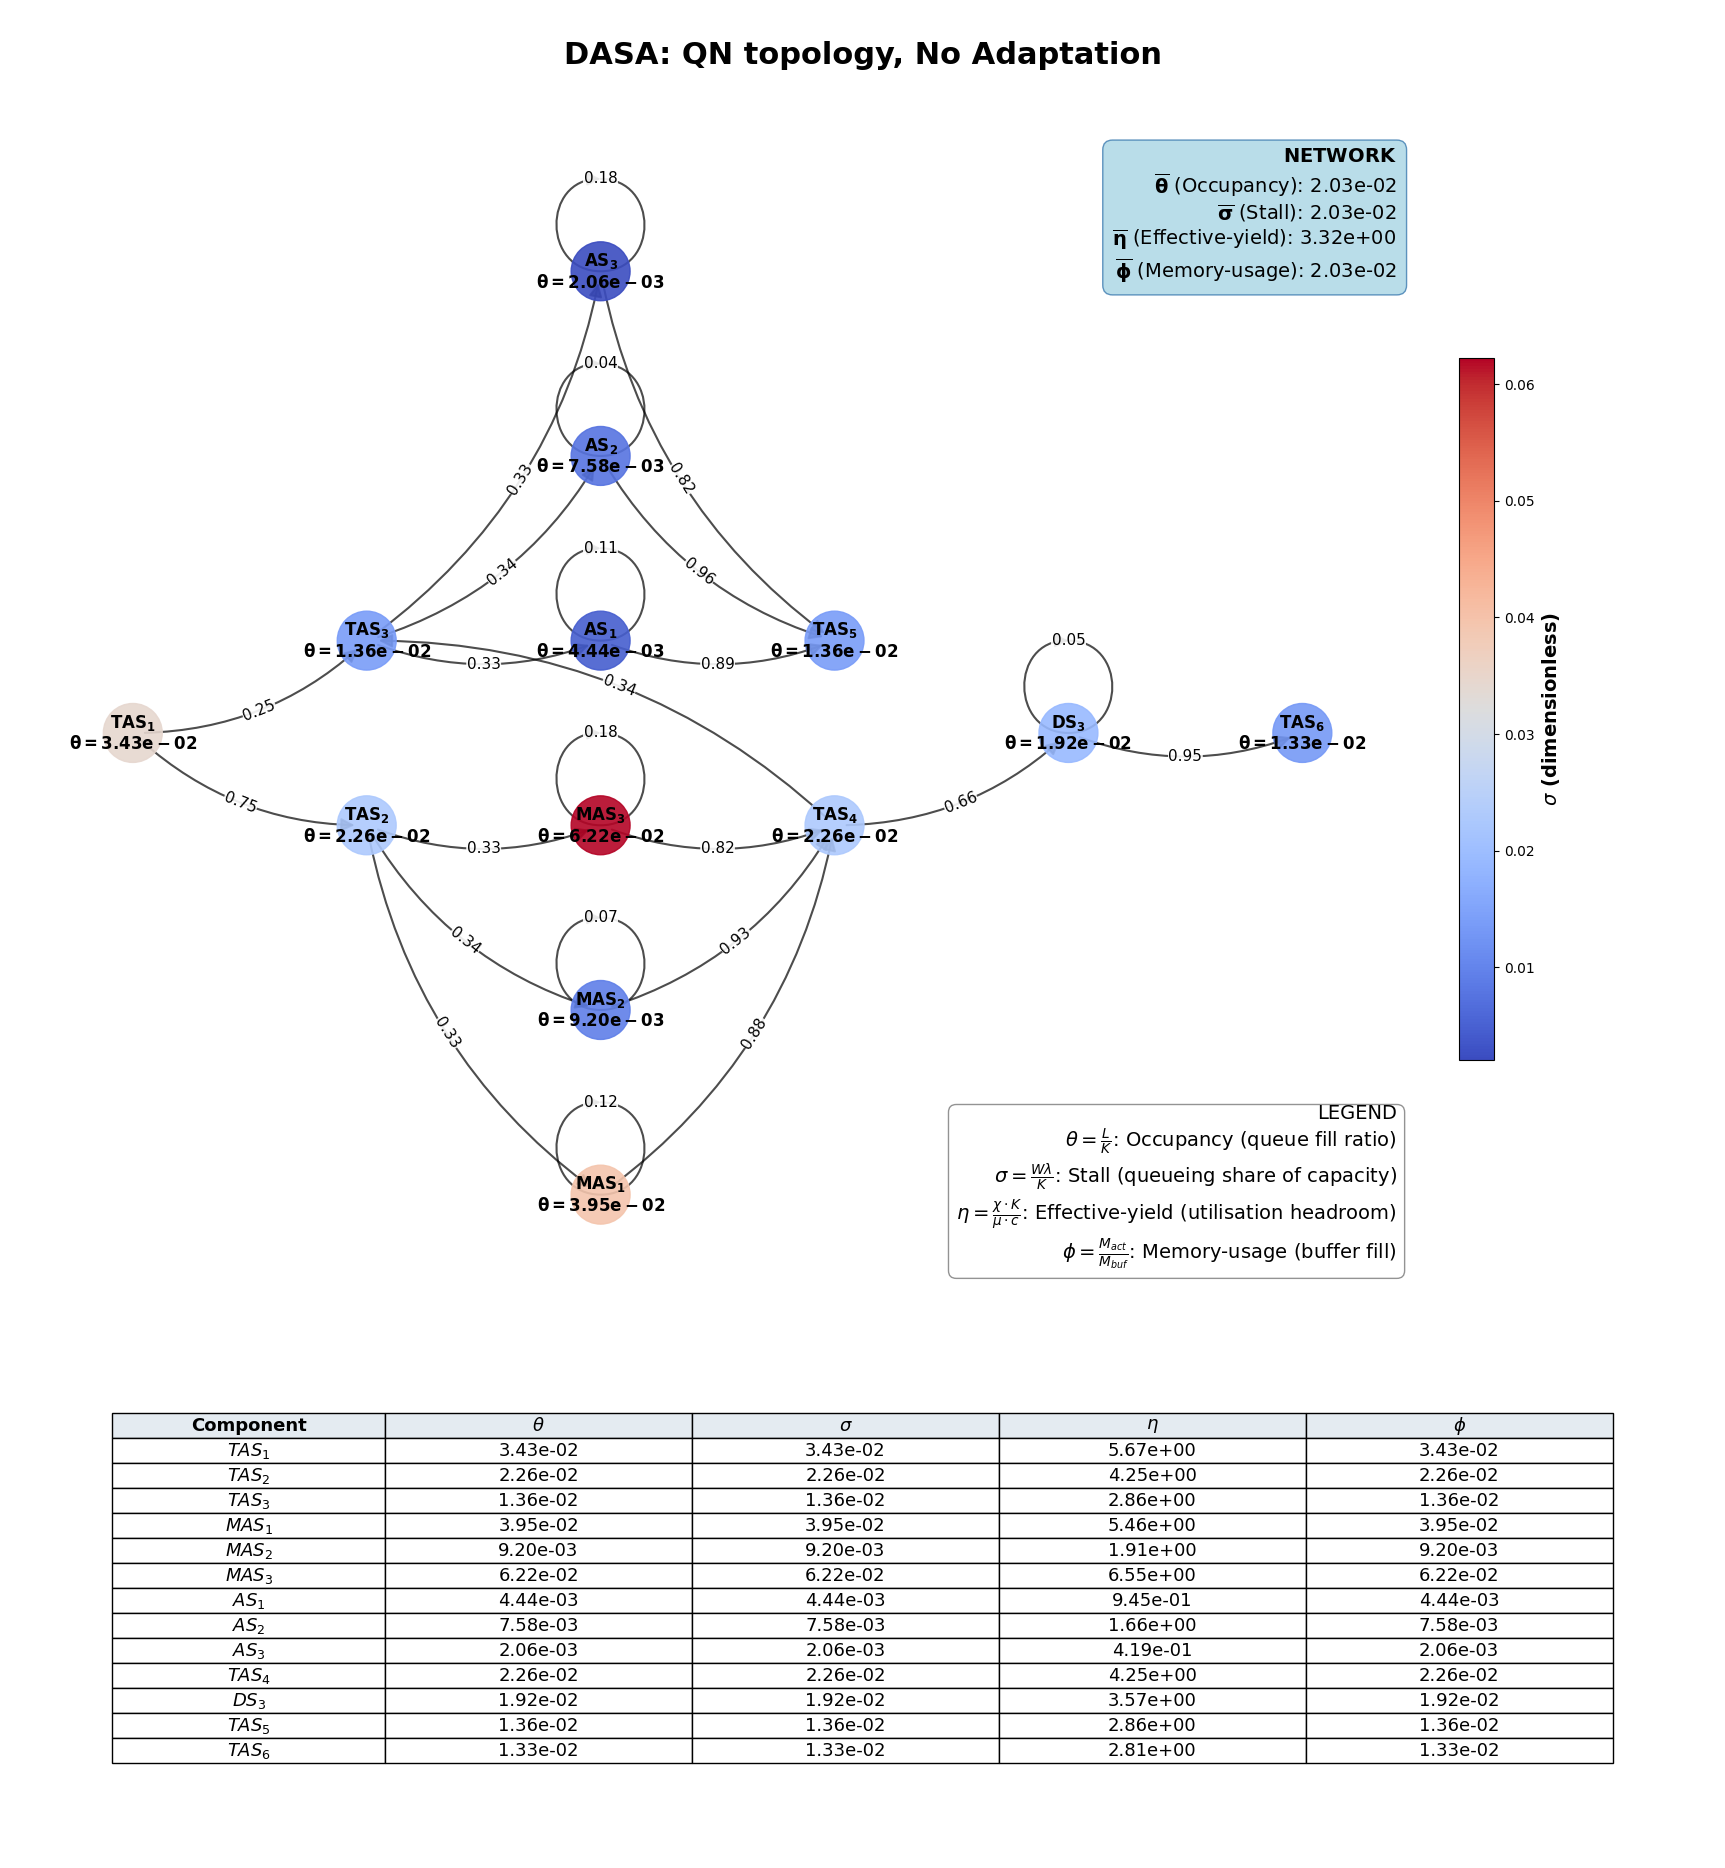

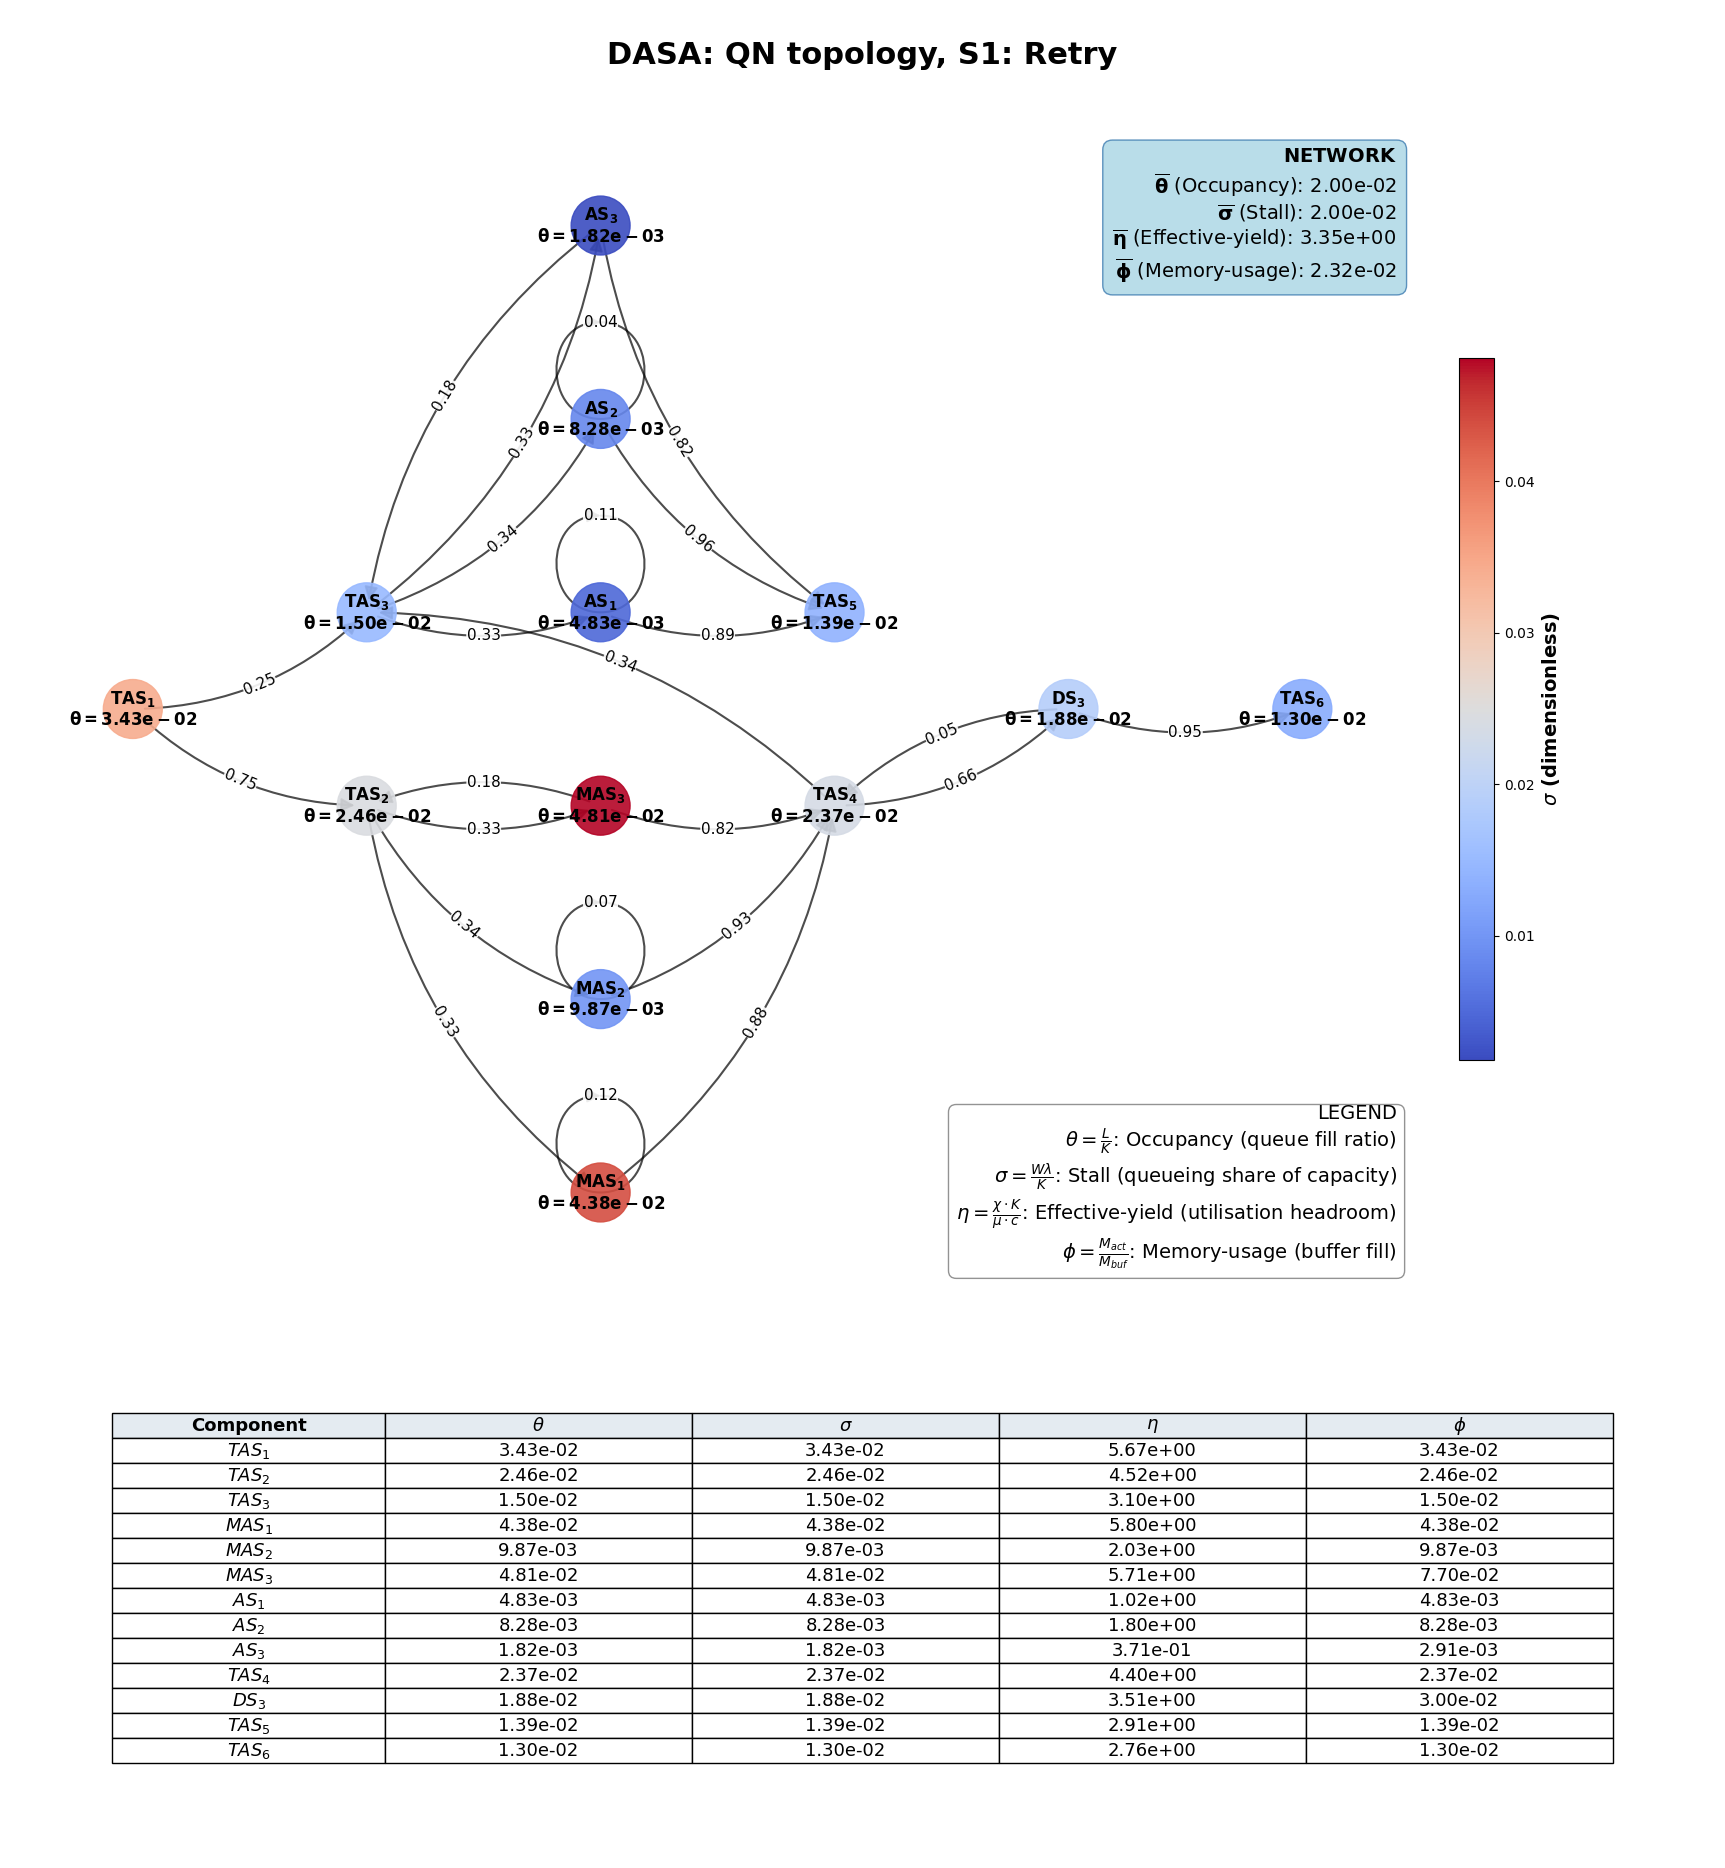

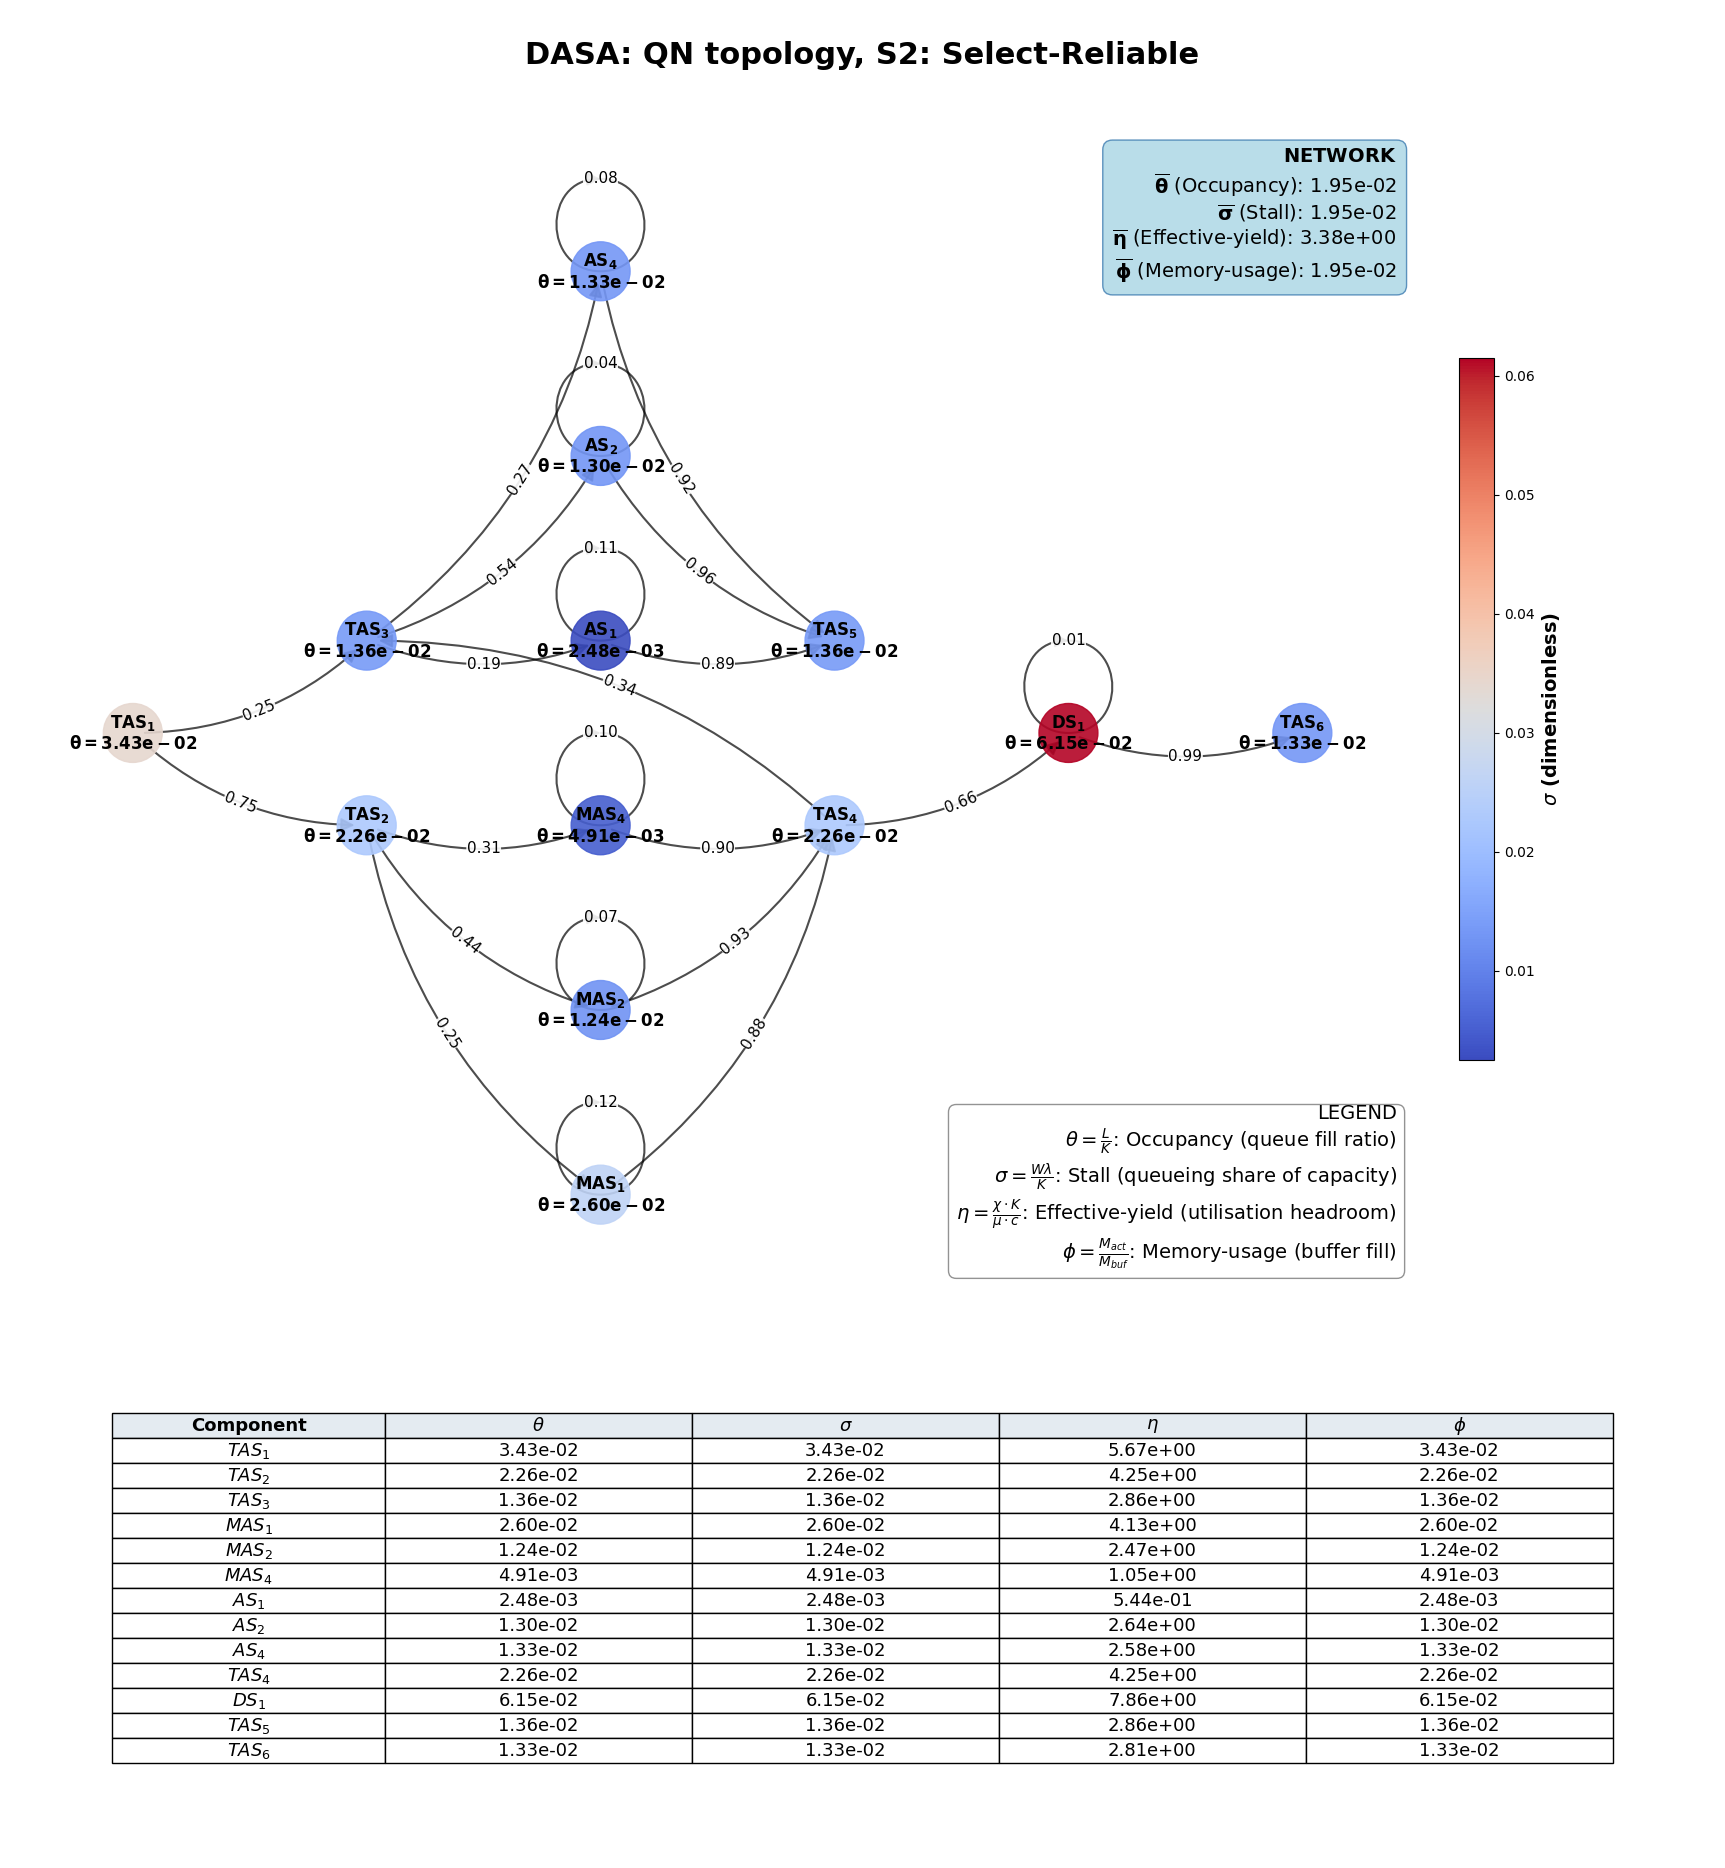

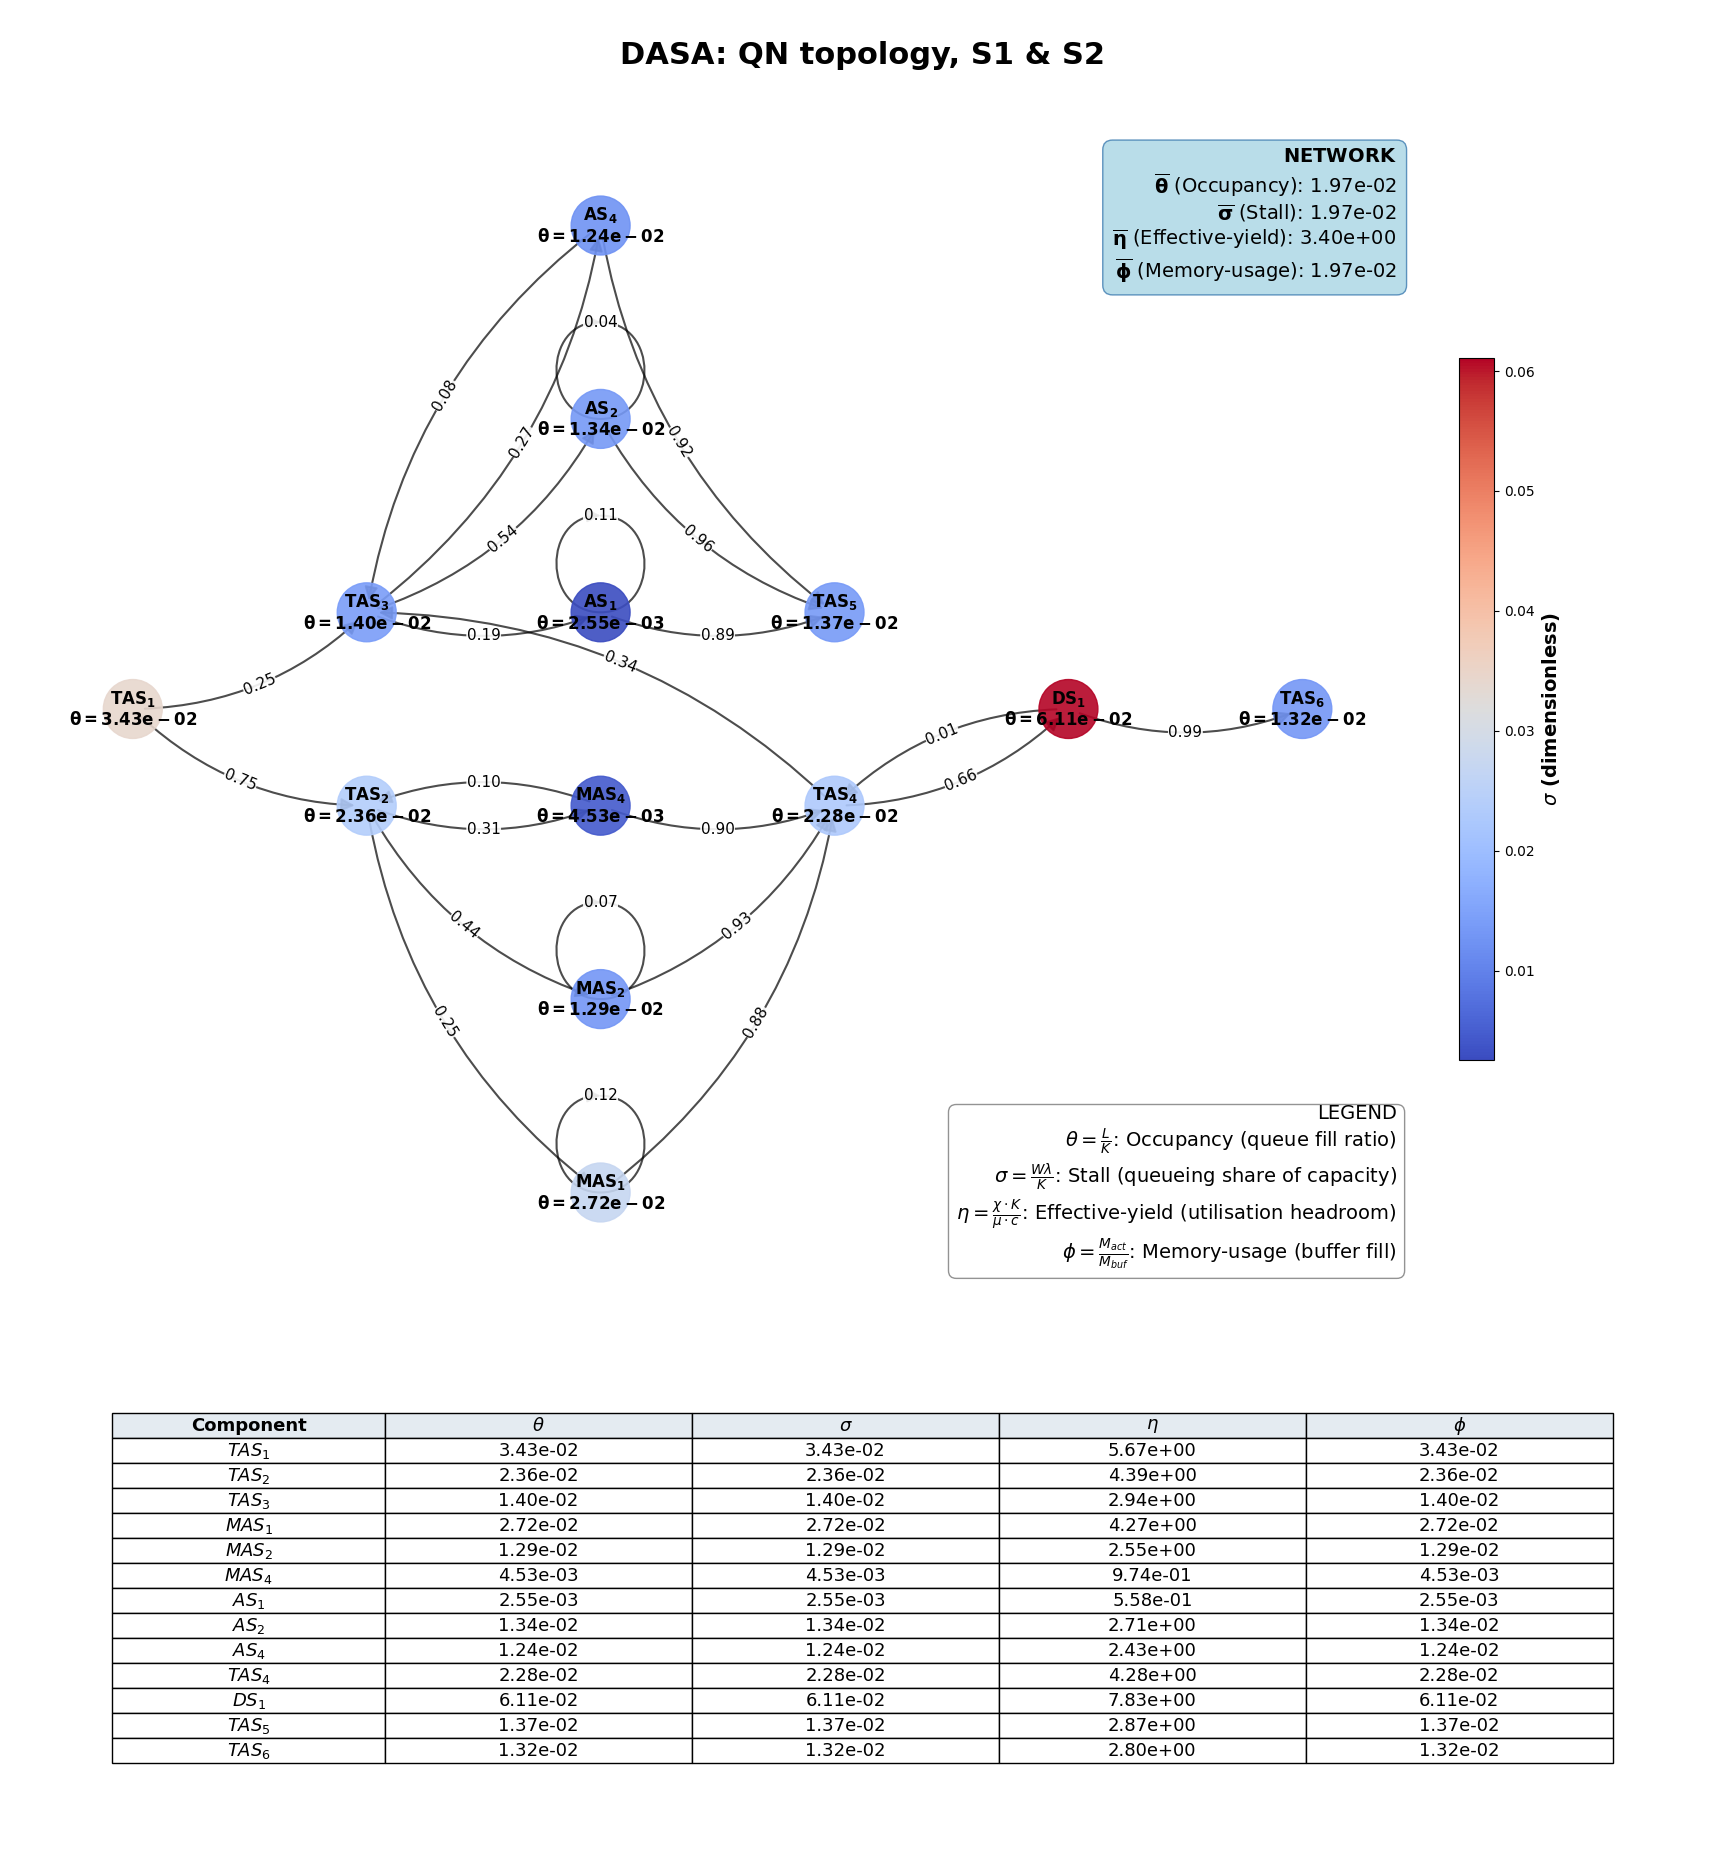

In [19]:
for a in ADAPTATIONS:
    plot_dim_topology(
        rout=results[a]["config"].routing,
        nds=nodes[a],
        color_by="sigma",
        title=f"DASA: QN topology, {DISPLAY[a]}",
        file_path=str(IMG_ROOT / a),
        fname="topology.png",
    )


## 5. Per-node coefficient heatmap (before vs after)

One row = one artifact. One column = one coefficient ($\theta$, $\sigma$,
$\eta$, $\phi$). Colour scaled per-column across ALL scenarios so the same
cell is comparable across adaptations. One subplot per adaptation.


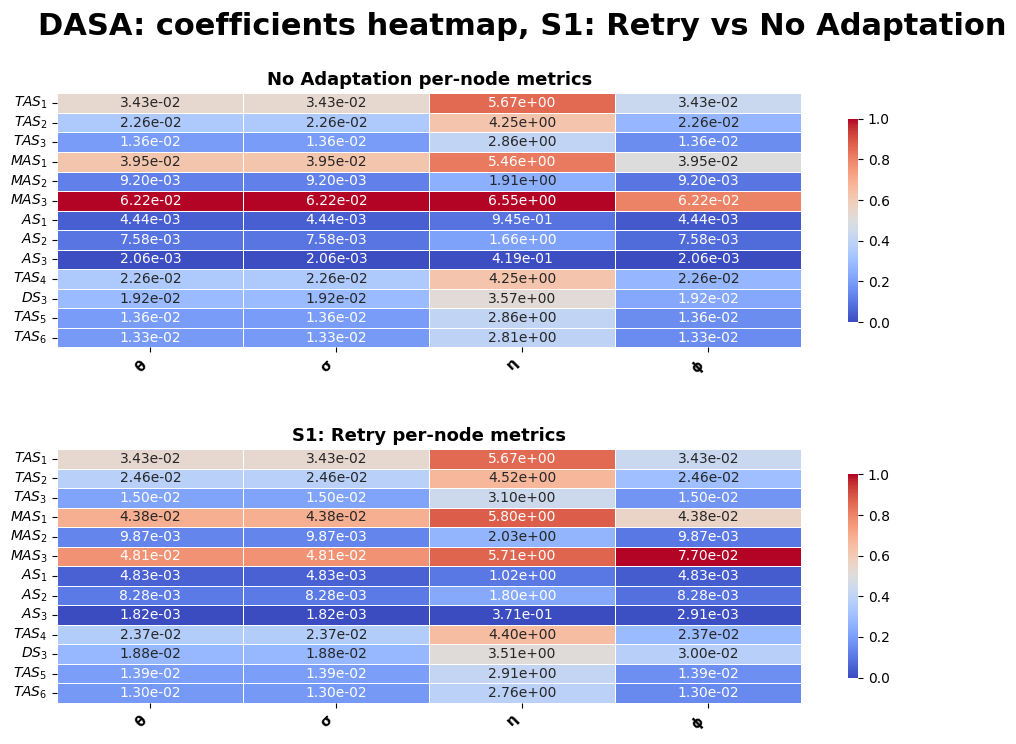

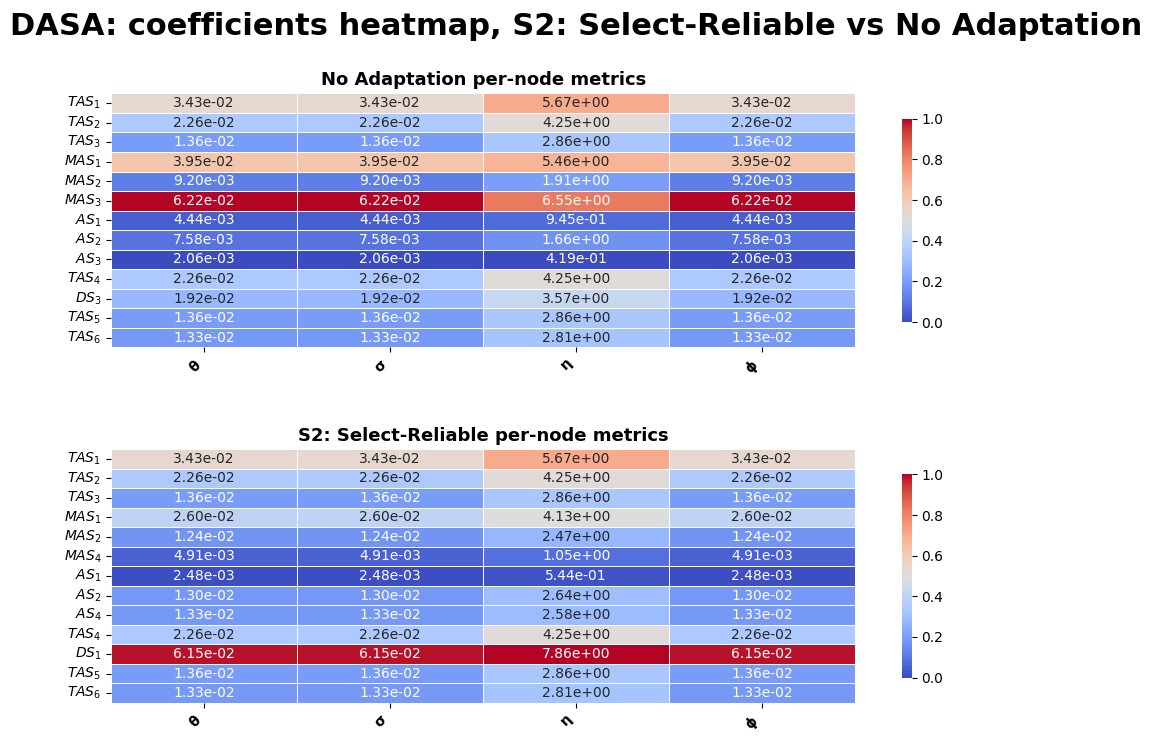

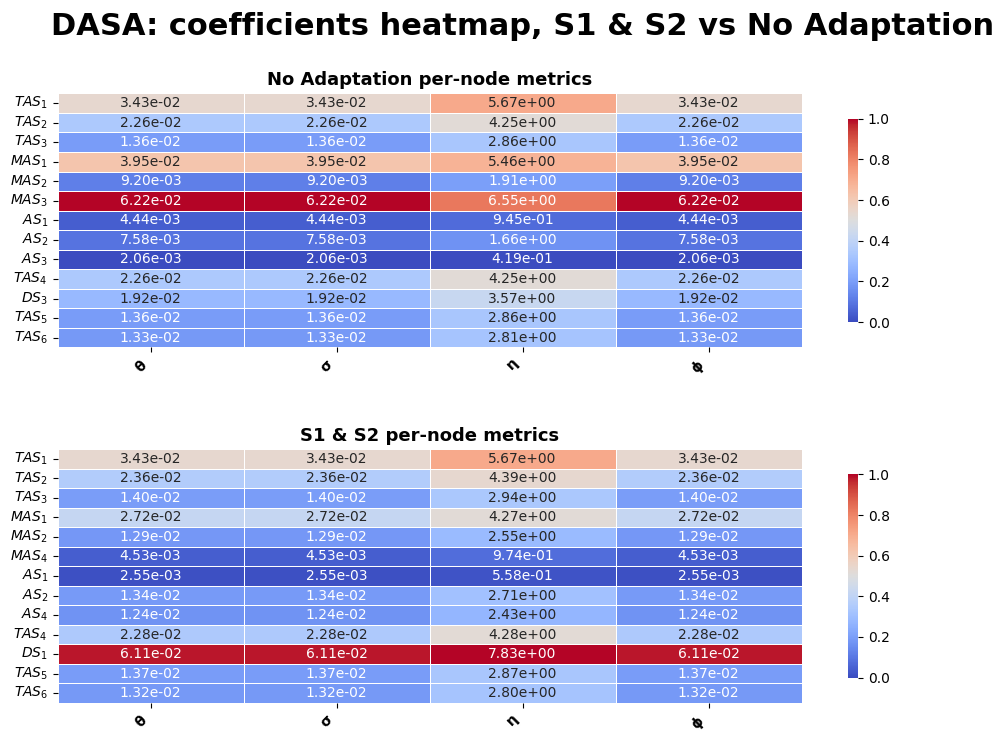

In [20]:
heat_metrics = ["theta", "sigma", "eta", "phi"]
heat_labels = [COEF_LABELS[m] for m in heat_metrics]

# plot_node_heatmap aligns rows positionally (iloc[i]); each panel's y-axis labels come from its own `key` column, so swap-slot rows show baseline's MAS_{3}/AS_{3}/DS_{3} and s2/aggregate's MAS_{4}/AS_{4}/DS_{1} at the same row position.
for a in ["s1", "s2", "aggregate"]:
    plot_node_heatmap(
        ndss=[nodes["baseline"], nodes[a]],
        names=[DISPLAY["baseline"], DISPLAY[a]],
        metrics=heat_metrics,
        labels=heat_labels,
        title=f"DASA: coefficients heatmap, {DISPLAY[a]} vs {DISPLAY['baseline']}",
        file_path=str(IMG_ROOT / a),
        fname="nd_heatmap_vs_baseline.png")


## 6. Per-node coefficient diffmap (vs baseline)

For every non-baseline adaptation, show the relative change
$(\text{other} - \text{dflt}) / |\text{dflt}|$ per artifact. Diverging
colour scale, zero-centred so improvements and degradations read with equal
intensity.


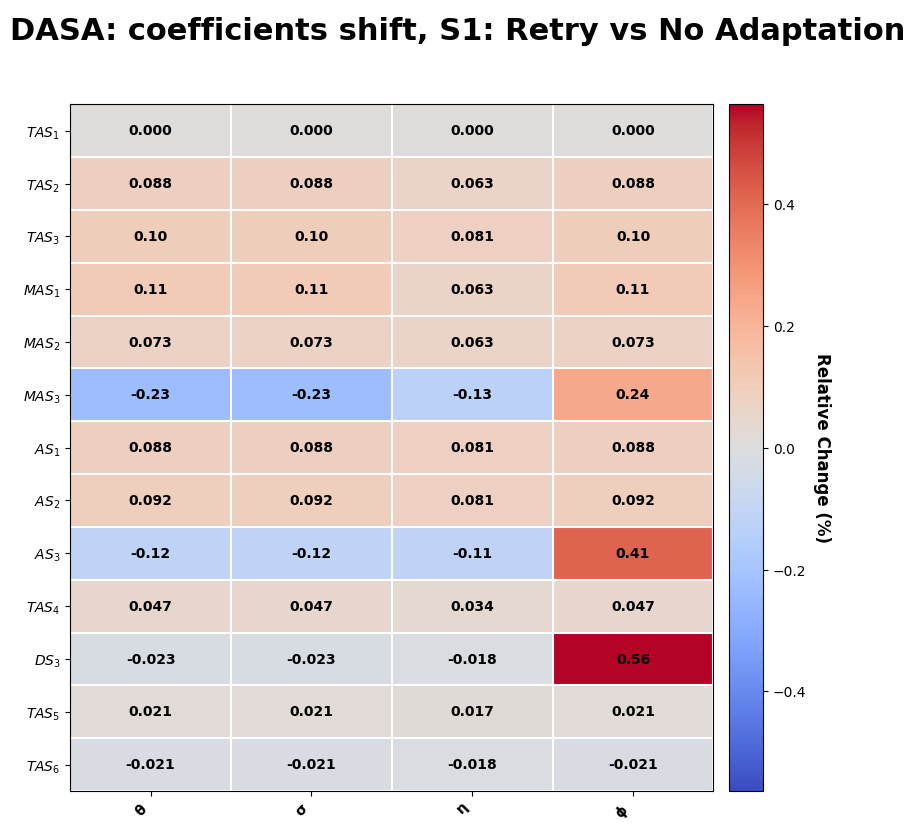

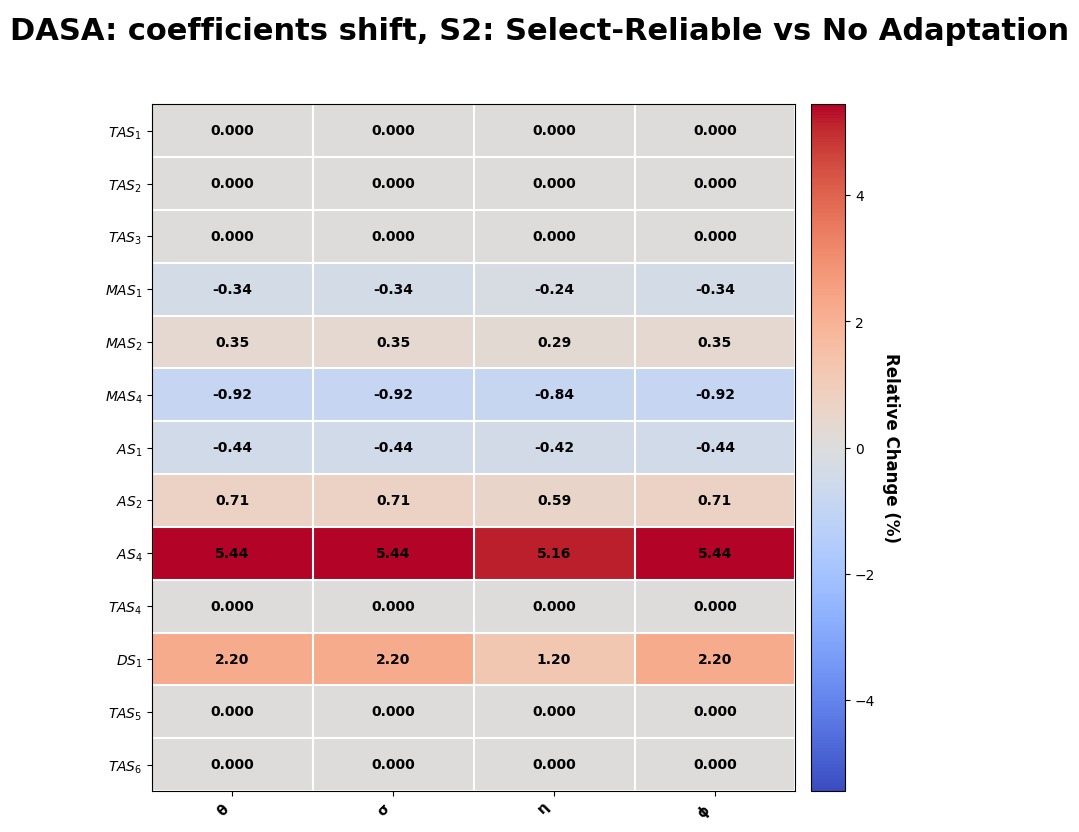

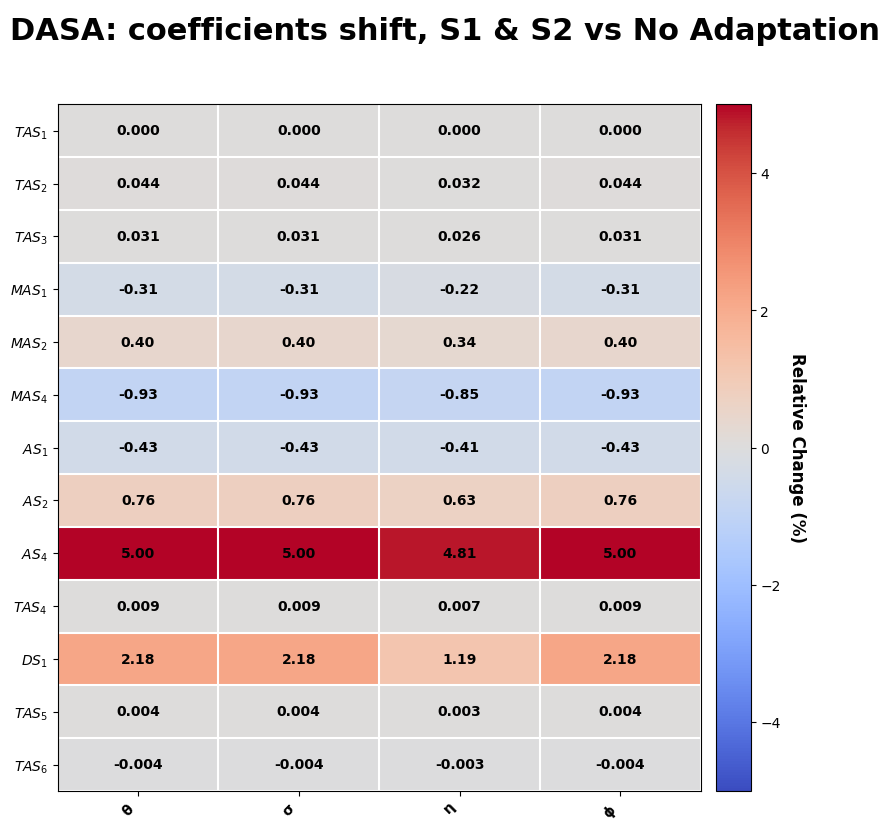

In [21]:
# positional-index inline delta (matches 01-analytic): align by slot since `key` may differ at swap slots
bl_nodes = nodes["baseline"]
for a in ["s1", "s2", "aggregate"]:
    ac_nodes = nodes[a]
    rows = []
    for i in range(len(ac_nodes)):
        b_row = bl_nodes.iloc[i]
        c_row = ac_nodes.iloc[i]
        row = {"key": c_row["key"]}
        for m in heat_metrics:
            b, c = float(b_row[m]), float(c_row[m])
            row[m] = ((c - b) / abs(b)) if b else 0.0
        rows.append(row)
    deltas = pd.DataFrame(rows)

    plot_node_diffmap(
        deltas=deltas,
        nodes=deltas["key"].tolist(),
        metrics=heat_metrics,
        labels=heat_labels,
        title=f"DASA: coefficients shift, {DISPLAY[a]} vs {DISPLAY['baseline']}",
        file_path=str(IMG_ROOT / a),
        fname="nd_diffmap_vs_baseline.png")


## 7. Network-wide coefficient bars

Headline comparison of the four coefficients across all four adaptations.
Linear y-axis (coefficients are O(1)); log scale would be misleading.


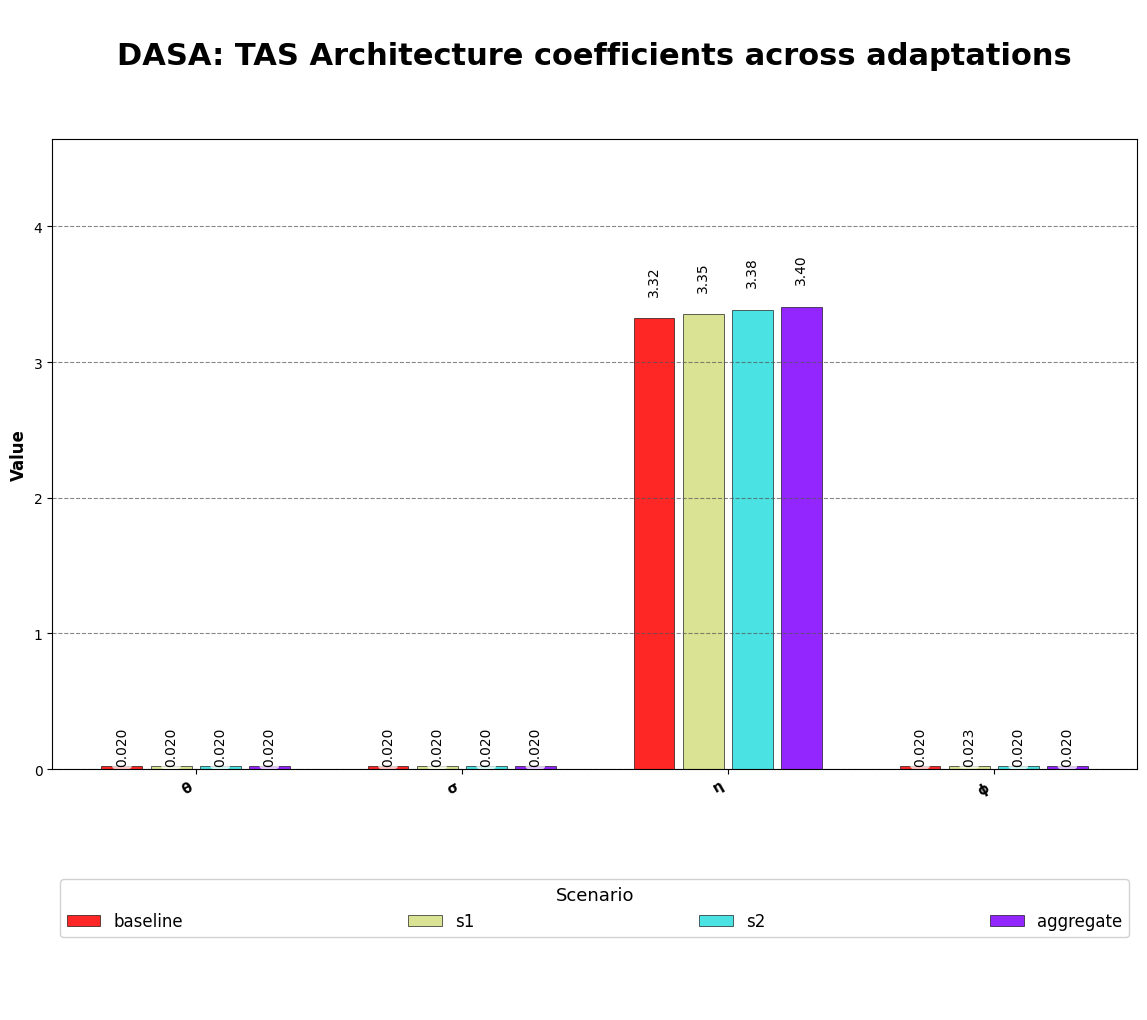

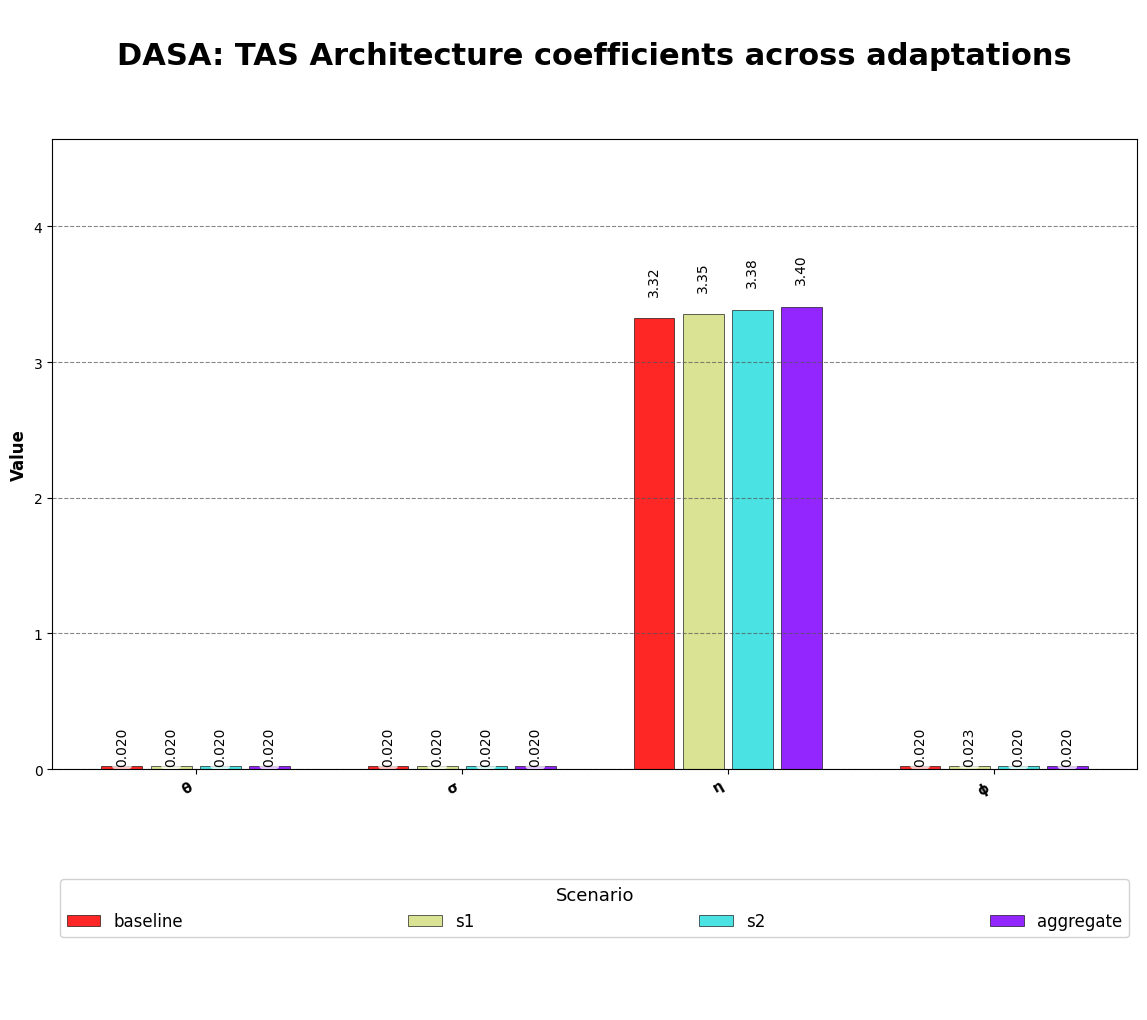

In [22]:
bar_metrics = ["theta", "sigma", "eta", "phi"]
bar_labels = [COEF_LABELS[m] for m in bar_metrics]

plot_arch_bars(
    nets=[nets[a] for a in ADAPTATIONS],
    names=ADAPTATIONS,
    metrics=bar_metrics,
    labels=bar_labels,
    logscale=False,
    title="DASA: TAS Architecture coefficients across adaptations",
    file_path=str(IMG_ROOT / "aggregate"),
    fname="net_bars_all.png",
)


## 8. Network-wide delta (% change vs baseline)

Fractional change for each non-baseline adaptation. Colours semantic: green
when the coefficient decreases (generally an improvement: less occupancy,
less stall, less buffer pressure); red when it increases.


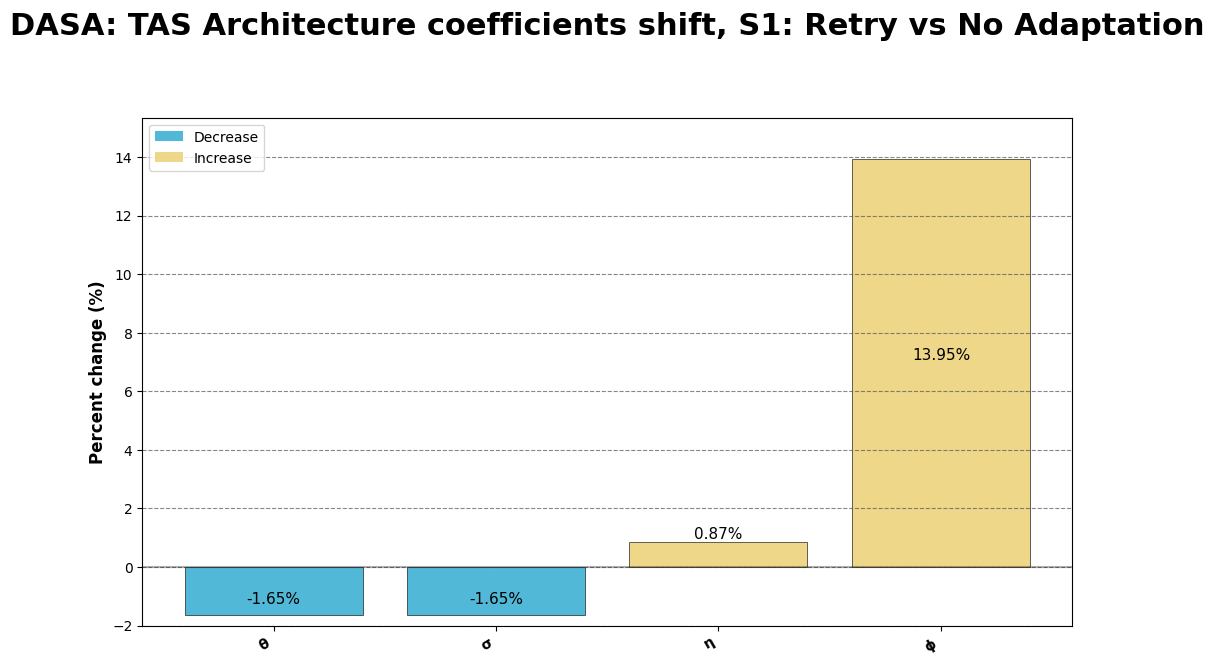

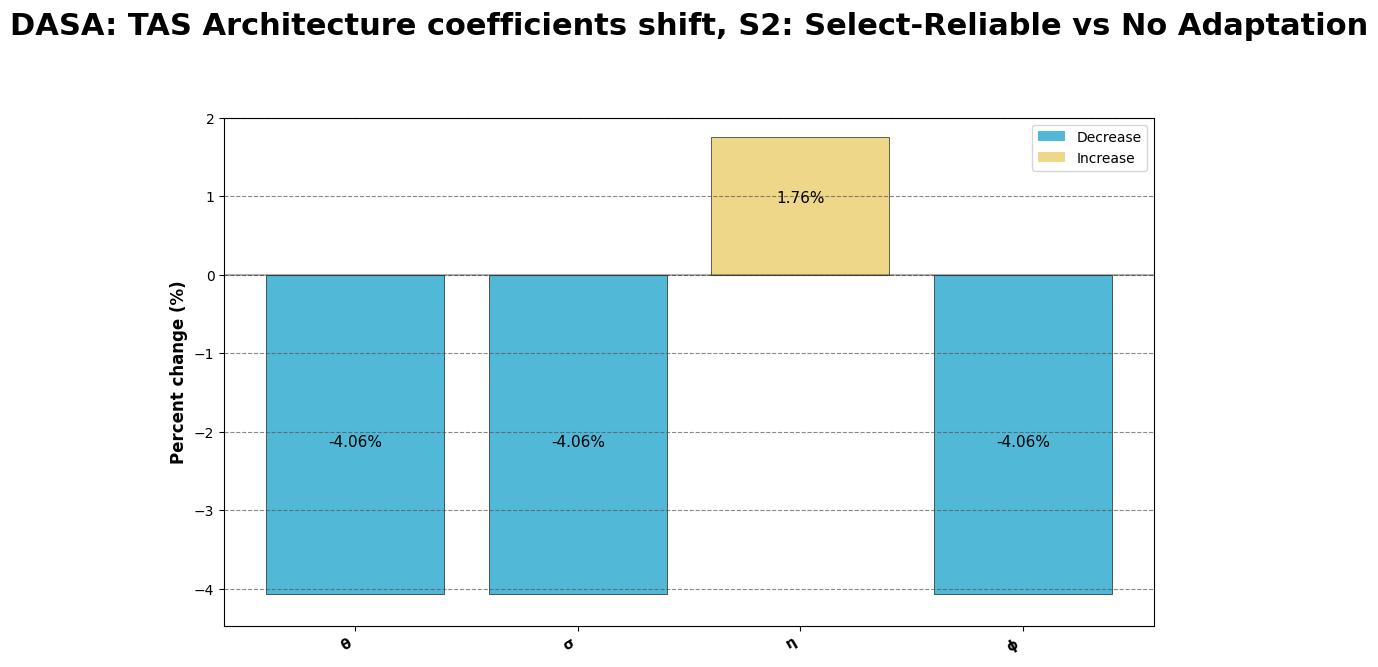

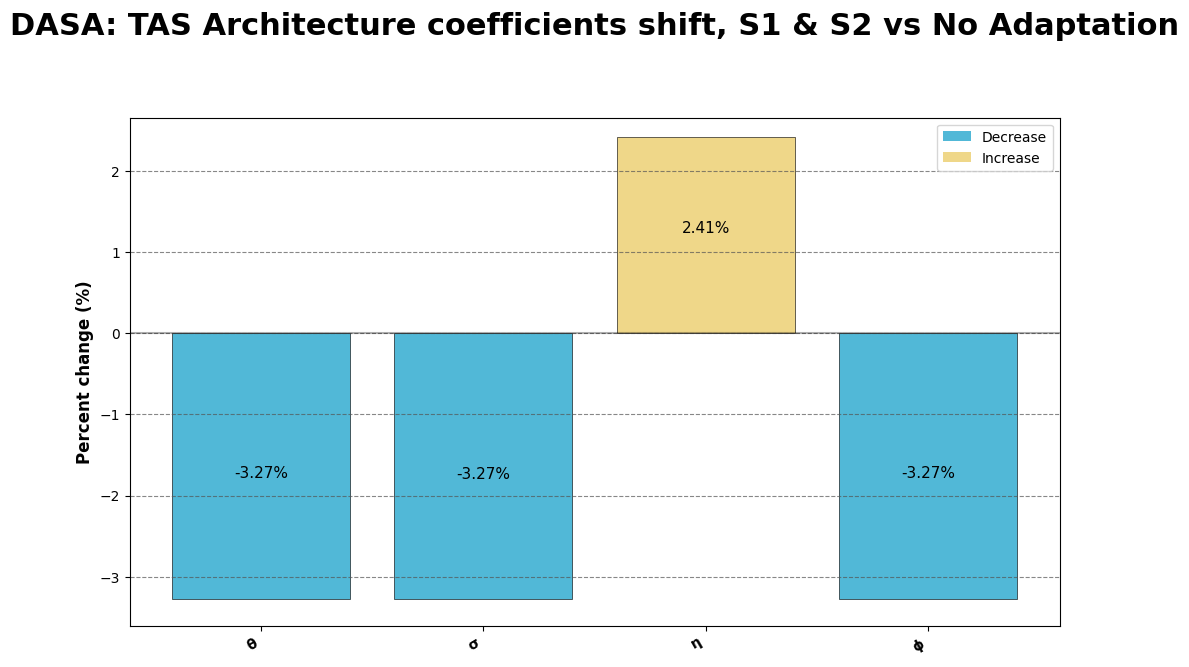

In [23]:
# inline delta-comprehension (matches 01-analytic): one fractional delta per metric per non-baseline adaptation
bl = nets["baseline"].iloc[0]
for a in ["s1", "s2", "aggregate"]:
    ac = nets[a].iloc[0]
    row = {
        m: (ac[m] - bl[m]) / bl[m] if bl[m] else 0.0
        for m in bar_metrics
    }
    plot_arch_delta(
        deltas=pd.DataFrame([row]),
        metrics=bar_metrics,
        labels=bar_labels,
        title=f"DASA: TAS Architecture coefficients shift, {DISPLAY[a]} vs {DISPLAY['baseline']}",
        file_path=str(IMG_ROOT / a),
        fname="net_delta_vs_baseline.png")


## 9. R1 / R2 verdict via dimensional bounds

The dimensional method produces R1 / R2 verdicts via Pi-group **bounds** rather than direct operational measurements:

$$\sigma_{R2} = \frac{W_{R2} \cdot \lambda_{z,\max}}{K_{\min}}, \qquad \eta_{R1} = \frac{\lambda_{z,\max} \cdot (1 + \varepsilon_{R1}) \cdot K_{\min}}{\mu_{\min} \cdot c_{\min}}$$

derived in [`notes/report-A.md`](notes/report-A.md) §6.4.1. The verdict reads architecture-level $\sigma_{\text{arch}}$ and $\eta_{\text{arch}}$ against the fixed bounds:

- $\sigma_{\text{arch}} < \sigma_{R2}$ $\iff$ $W_{\text{net}} < W_{R2}$ $\iff$ **R2 PASS**
- $\eta_{\text{arch}} < \eta_{R1}$ $\iff$ $\varepsilon_{\text{TAS}}^{\text{e2e}} < \varepsilon_{R1}$ $\iff$ **R1 PASS**

Thresholds: $W_{R2} = 26$ ms (from [`data/reference/baseline.json`](data/reference/baseline.json)) and $\varepsilon_{R1} = 0.01$ (per-call). Denominator parameters are fixed at baseline's worst-case values across all adaptations (reference-frame caveat: report-A §6.4.1).

In [25]:
import json

# R1 / R2 operational thresholds (data/reference/baseline.json).
_ref = json.loads(Path("data/reference/baseline.json").read_text(encoding="utf-8"))
R2_LIMIT = _ref["requirements"]["R2"]["threshold"]  # s
R1_LIMIT = _ref["requirements"]["R1"]["threshold"]  # fraction

# Bound parameters fixed at baseline's worst-case (report-A §6.4.1 reference frame).
cfg = results["baseline"]["config"]
lam_max = max(a.lambda_z for a in cfg.artifacts)
K_min   = min(a.K for a in cfg.artifacts)
mu_min  = min(a.mu for a in cfg.artifacts)
c_min   = min(a.c for a in cfg.artifacts)

SIGMA_R2 = R2_LIMIT * lam_max / K_min
ETA_R1   = lam_max * (1 + R1_LIMIT) * K_min / (mu_min * c_min)

print(f"R2 bound  sigma_R2 = {SIGMA_R2:.4f}   "
      f"(W_R2={R2_LIMIT}s, lambda_z_max={lam_max}, K_min={K_min})")
print(f"R1 bound  eta_R1   = {ETA_R1:.4f}   "
      f"(eps_R1={R1_LIMIT}, mu_min={mu_min}, c_min={c_min})")

verdict_rows = []
for a in ADAPTATIONS:
    net = nets[a].iloc[0]
    sigma_arch = float(net["sigma"])
    eta_arch   = float(net["eta"])
    verdict_rows.append({
        "adaptation":   a,
        "sigma_arch":   sigma_arch,
        "sigma_R2":     SIGMA_R2,
        "R2 pass":      sigma_arch < SIGMA_R2,
        "eta_arch":     eta_arch,
        "eta_R1":       ETA_R1,
        "R1 pass":      eta_arch < ETA_R1,
    })
pd.DataFrame(verdict_rows).set_index("adaptation")

R2 bound  sigma_R2 = 0.4030   (W_R2=0.026s, lambda_z_max=248.0, K_min=16)
R1 bound  eta_R1   = 26.7179   (eps_R1=0.01, mu_min=150.0, c_min=1)


,sigma_arch,sigma_R2,R2 pass,eta_arch,eta_R1,R1 pass
adaptation,,,,,,
baseline,0.020332,0.403,True,3.323929,26.717867,True
s1,0.019997,0.403,True,3.352747,26.717867,True
s2,0.019507,0.403,True,3.382390,26.717867,True
aggregate,0.019667,0.403,True,3.404124,26.717867,True


## 10. Top-3 most sensitive variables per coefficient (baseline)

Symbolic sensitivity at variable means. For each coefficient we show the
three variables with the largest $|\partial \text{coeff} / \partial x|$ on
the baseline $TAS_{1}$ artifact. Orientation (sign) is documented in
`notes/workflow.md`.

In [24]:
SAMPLE_ARTIFACT = "TAS_{1}"
sens = results["baseline"]["artifacts"][SAMPLE_ARTIFACT]["sensitivity"]

DERIVED_COEFFS = [
    (r"$\mathbf{\theta}$", "SEN_{\\theta_{TAS_{1}}}"),
    (r"$\mathbf{\sigma}$", "SEN_{\\sigma_{TAS_{1}}}"),
    (r"$\mathbf{\eta}$",   "SEN_{\\eta_{TAS_{1}}}"),
    (r"$\mathbf{\phi}$",   "SEN_{\\phi_{TAS_{1}}}"),
]

sens_rows = []
for label, key in DERIVED_COEFFS:
    vmap = sens.get(key, {})
    top3 = sorted(vmap.items(),
                   key=lambda kv: abs(kv[1]),
                   reverse=True)[:3]
    for v_sym, val in top3:
        sens_rows.append({
            "coefficient": label,
            "variable": v_sym,
            "d(coeff)/d(var)": val,
        })

pd.DataFrame(sens_rows)


,coefficient,variable,d(coeff)/d(var)
0,$\mathbf{\theta}$,L_{TAS_{1}},0.062500
1,$\mathbf{\theta}$,K_{TAS_{1}},-0.002143
2,$\mathbf{\sigma}$,W_{TAS_{1}},15.500000
3,$\mathbf{\sigma}$,K_{TAS_{1}},-0.002143
4,$\mathbf{\sigma}$,\lambda_{TAS_{1}},0.000138
5,$\mathbf{\eta}$,c_{TAS_{1}},-5.668571
6,$\mathbf{\eta}$,K_{TAS_{1}},0.354286
7,$\mathbf{\eta}$,\chi_{TAS_{1}},0.022857
8,$\mathbf{\phi}$,M_{act_{TAS_{1}}},0.000059
9,$\mathbf{\phi}$,M_{buf_{TAS_{1}}},-0.000002


## Summary

Dimensional analysis produces the same four derived coefficients per artifact under every adaptation. **Pi-group expressions are invariant** across adaptations (same variable set, different setpoints); this is the Buckingham guarantee.

§9 above delivers the **R1 / R2 verdict via dimensional bounds** ($\sigma_{R2}$ and $\eta_{R1}$ from report-A §6.4.1), so the dimensional view is now self-contained: trade-off geometry + viable-region check + scenario fulfilment, all from Pi-groups alone. `comparison.ipynb` will still triangulate the three methods in the last notebook of the pipeline.

Configuration-sweep yoly diagrams (showing the full coefficient cloud across a $(\mu, c, K)$ grid) live in `yoly.ipynb`; Phase 3b/c of the build plan.